In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.__version__

'2.3.3'

In [3]:
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


BASIC EDA

In [4]:
df.shape

(16000, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [6]:
df.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [7]:
# Missing Values Check

df.isnull().sum().sort_values(ascending=False)

duration        16000
country           466
cast              204
director          132
description       132
genres            107
type                0
show_id             0
title               0
date_added          0
rating              0
release_year        0
language            0
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

Select Features for Clustering

In [8]:
features = df[
    ['release_year', 'duration', 'popularity',
     'vote_average', 'vote_count']
].dropna()

In [9]:
features.head()

,release_year,duration,popularity,vote_average,vote_count


In [11]:
df[['duration', 'popularity', 'vote_average', 'vote_count']].head(10)

,duration,popularity,vote_average,vote_count
0,NaN,203.893,6.380,7449
1,NaN,156.242,8.369,37119
2,NaN,121.191,7.744,19327
3,NaN,111.762,7.600,11638
4,NaN,110.044,7.800,13259
5,NaN,101.551,8.200,24282
6,NaN,96.385,6.500,6082
7,NaN,95.255,6.800,21222
8,NaN,93.281,6.394,6212
9,NaN,90.230,6.416,748


In [12]:
features = df[
    ['release_year', 'popularity', 'vote_average', 'vote_count']
]

In [13]:
features = features.apply(pd.to_numeric, errors='coerce')
features = features.dropna()

In [14]:
features.shape

(16000, 4)

In [15]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [16]:
scaled_features.shape

(16000, 4)

K-MEANS CLUSTERING

In [17]:
# Elbow Method (Find best K)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

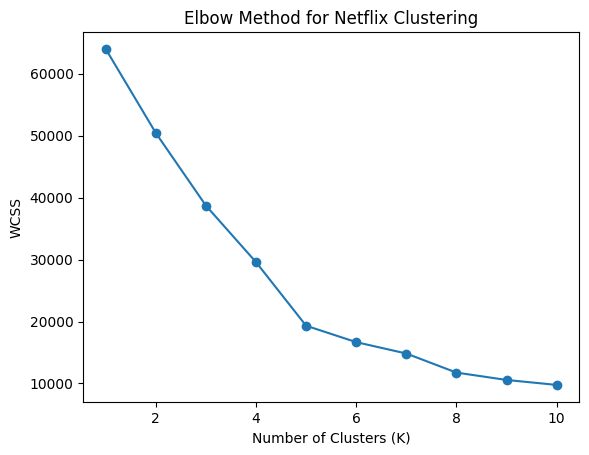

In [18]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Netflix Clustering")
plt.show()

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [20]:
features['cluster'] = clusters
features.head()

,release_year,popularity,vote_average,vote_count,cluster
0,2010,203.893,6.380,7449,2
1,2010,156.242,8.369,37119,2
2,2010,121.191,7.744,19327,2
3,2010,111.762,7.600,11638,2
4,2010,110.044,7.800,13259,2


In [21]:
features.groupby('cluster').mean()

,release_year,popularity,vote_average,vote_count
cluster,,,,
0,2013.409297,11.753139,6.138919,484.696901
1,2023.912867,11.739255,0.184751,0.647416
2,2015.675676,73.390759,7.068098,10408.943867
3,2024.400000,2155.952700,7.046800,1032.100000
4,2021.067652,24.122303,6.494225,405.400085


In [22]:
# cluster labels to dataframe

cluster_names = {
    0: "Legacy Content",
    1: "Cold Start",
    2: "Blockbuster Hits",
    3: "Trending Now",
    4: "Steady Performers"
}

features['cluster_label'] = features['cluster'].map(cluster_names)

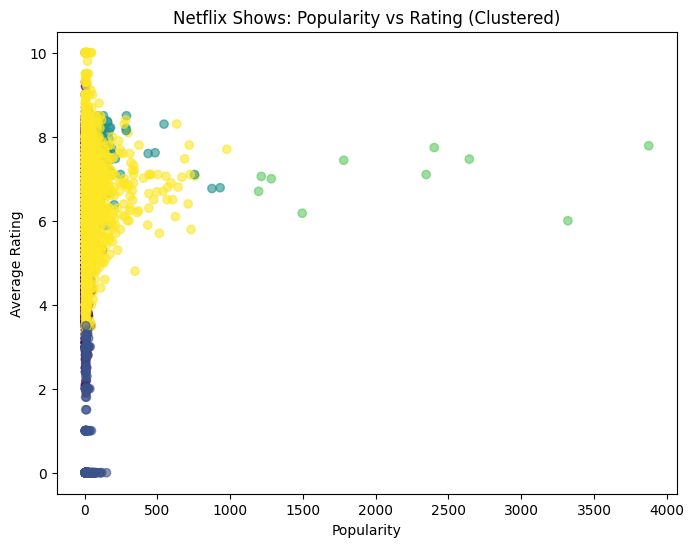

In [24]:
# Scatter Plot — Popularity vs Rating (Cluster-wise)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    features['popularity'],
    features['vote_average'],
    c=features['cluster'],
    alpha=0.6
)

plt.xlabel("Popularity")
plt.ylabel("Average Rating")
plt.title("Netflix Shows: Popularity vs Rating (Clustered)")
plt.show()

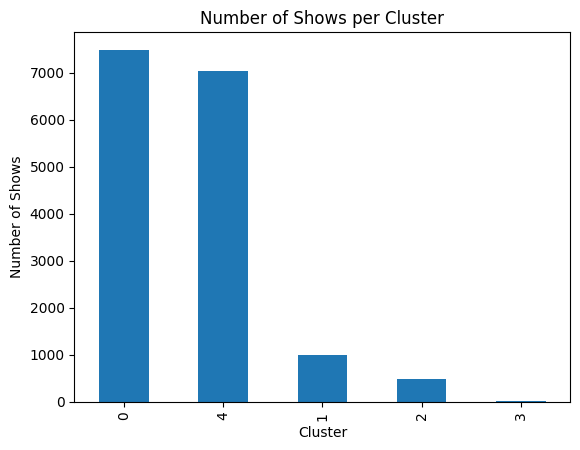

In [25]:
# Cluster Size Distribution 

features['cluster'].value_counts().plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Number of Shows")
plt.title("Number of Shows per Cluster")
plt.show()

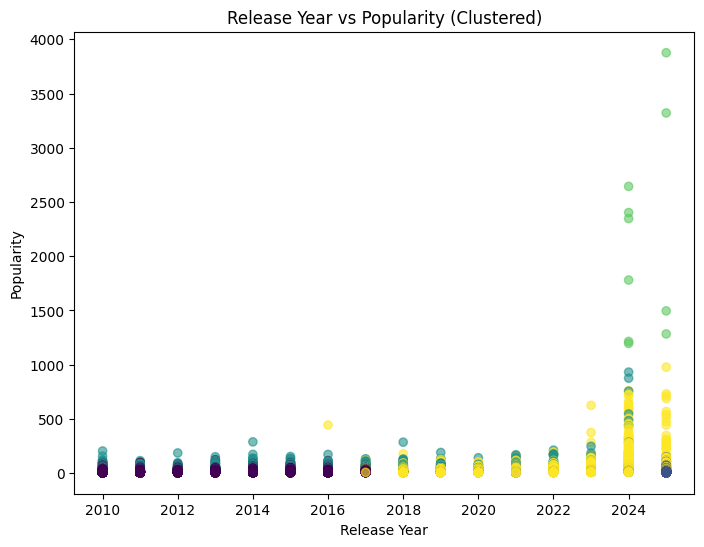

In [26]:
# Release Year vs Popularity - Shows Netflix’s recent content strategy

plt.figure(figsize=(8,6))
plt.scatter(
    features['release_year'],
    features['popularity'],
    c=features['cluster'],
    alpha=0.6
)

plt.xlabel("Release Year")
plt.ylabel("Popularity")
plt.title("Release Year vs Popularity (Clustered)")
plt.show()

In [27]:
cluster_names = {
    0: "Low-Engagement Legacy Titles",
    1: "Cold-Start New Releases",
    2: "High-Impact Blockbuster Content",
    3: "Viral & Trending Titles",
    4: "Consistent Mid-Performers"
}

features['cluster_label'] = features['cluster'].map(cluster_names)

PCA → 2D CLUSTER PLOT

In [29]:
# Step 1 - Import PCA

from sklearn.decomposition import PCA

In [30]:
# Step 2️ -  Apply PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

In [31]:
# Step 3 - Create PCA DataFrame

pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = features['cluster']

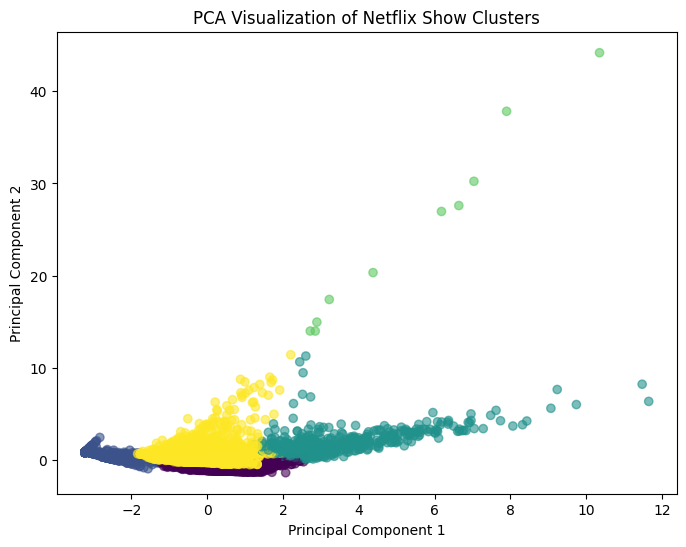

In [32]:
# Step 4 - Plot PCA Clusters

plt.figure(figsize=(8,6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Netflix Show Clusters")
plt.show()

In [33]:
cluster_profile = features.groupby('cluster_label').mean()
cluster_profile

,release_year,popularity,vote_average,vote_count,cluster
cluster_label,,,,,
Cold-Start New Releases,2023.912867,11.739255,0.184751,0.647416,1.0
Consistent Mid-Performers,2021.067652,24.122303,6.494225,405.400085,4.0
High-Impact Blockbuster Content,2015.675676,73.390759,7.068098,10408.943867,2.0
Low-Engagement Legacy Titles,2013.409297,11.753139,6.138919,484.696901,0.0
Viral & Trending Titles,2024.400000,2155.952700,7.046800,1032.100000,3.0


In [34]:
# Add Silhouette Score

from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, features['cluster'])
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.442


In [35]:
# Add PCA Explained Variance

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.33851795 0.28849019]
Total variance explained: 0.6270081406483707


In [36]:
# Feature Engineering

features['content_age'] = 2025 - df['release_year']

In [38]:
# Save Model & Scaler

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model and scaler
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [39]:
kmeans_loaded = joblib.load("models/kmeans_model.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

sample = [[2022, 50, 7.5, 1200]]
sample_scaled = scaler_loaded.transform(sample)
kmeans_loaded.predict(sample_scaled)

c:\Users\notan\Desktop\CodeVault\Data Science Projects\Netflix Show Clustering\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)